# Détection d’anomalies des ventes

Dans cette section, nous analysons les résidus du modèle de prévision afin d’identifier des journées présentant des comportements anormaux.

L’objectif est de détecter automatiquement des variations inhabituelles non expliquées par la saisonnalité ou la tendance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results = pd.read_csv("../data/processed/forecast_results.csv")

results["ds"] = pd.to_datetime(results["ds"])
results = results.set_index("ds")

results.head()

,y_true,y_pred,residual
ds,,,
2022-06-01,638.05,769.743667,-131.693667
2022-06-02,594.90,770.528000,-175.628000
2022-06-03,734.90,836.869667,-101.969667
2022-06-04,1106.35,979.266167,127.083833
2022-06-05,1756.10,1589.937333,166.162667


## Méthodologie

Nous utilisons une approche statistique basée sur le Z-score des résidus.

Le résidu correspond à la différence entre :
- la valeur réelle des ventes
- la valeur prédite par le modèle

Formule du Z-score :

Z = (résidu - moyenne des résidus) / écart-type des résidus

Une anomalie est détectée lorsque |Z| > 3.
Ce seuil correspond à un événement statistiquement rare.

In [5]:
results["residual_z"] = (
    results["residual"] - results["residual"].mean()
) / results["residual"].std()

## Nombre d’anomalies détectées

Nous comptons le nombre de journées considérées comme anormales selon le seuil défini.
Cela permet d’évaluer si la détection est cohérente et réaliste.


In [6]:
results["anomaly"] = np.abs(results["residual_z"]) > 3

results["anomaly"].value_counts()

anomaly
False    120
True       2
Name: count, dtype: int64

## Visualisation des anomalies

Les points rouges représentent les journées où le modèle n’a pas correctement anticipé la variation des ventes.

Ces anomalies peuvent correspondre à :
- un événement exceptionnel
- une rupture de stock
- un jour férié
- une promotion importante
- une erreur de saisie ou de système

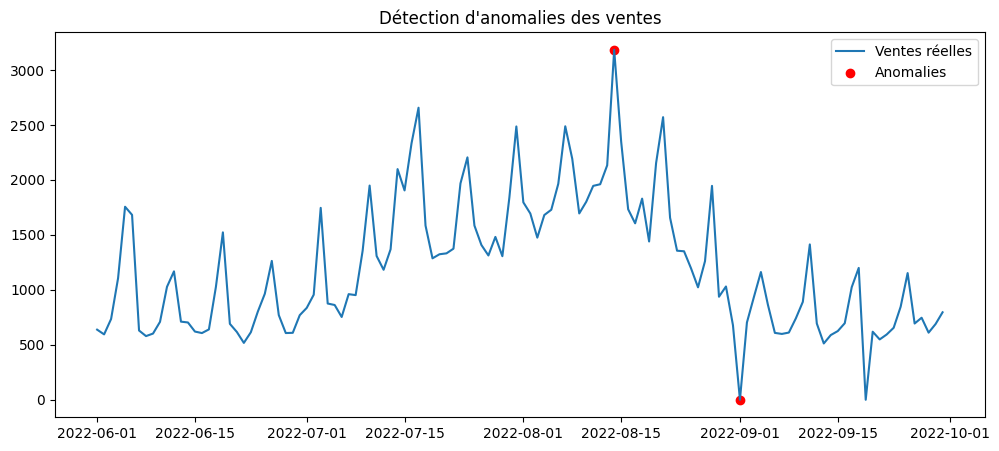

In [7]:
plt.figure(figsize=(12,5))

plt.plot(results.index, results["y_true"], label="Ventes réelles")

anomalies = results[results["anomaly"]]

plt.scatter(
    anomalies.index,
    anomalies["y_true"],
    color="red",
    label="Anomalies"
)

plt.legend()
plt.title("Détection d'anomalies des ventes")
plt.show()

## Conclusion

La détection d’anomalies permet d’identifier automatiquement des comportements atypiques dans les ventes.

Cette approche est utilisée en entreprise pour :
- surveiller la performance commerciale
- détecter des incidents opérationnels
- identifier des opportunités ou des risques

La combinaison prévision + analyse des résidus constitue une base solide pour un système de monitoring intelligent.